# Image Processing Fundamentals: Setup, Fourier Transform, and Ideal Low Pass Filter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 8.9 MB/s eta 0:00:00


Saving photo-1773489425384-7fd20c7729dd.avif to photo-1773489425384-7fd20c7729dd.avif


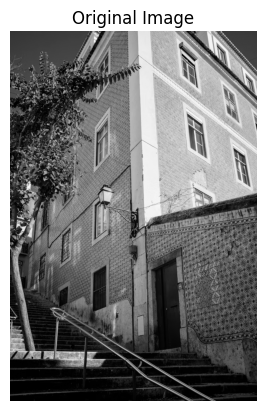

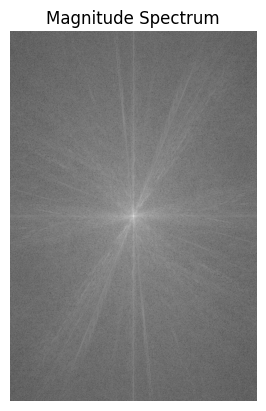

interactive(children=(IntSlider(value=50, description='D0', max=200, min=10, step=10), Output()), _dom_classes…

<function __main__.ideal_low_pass(D0)>

In [ ]:
!pip install opencv-python ipywidgets

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import ipywidgets as widgets
from IPython.display import display

# Upload Image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path, 0)

plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

# Fourier Transform
f = np.fft.fft2(image)
fshift = np.fft.fftshift(f)
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)

plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Magnitude Spectrum")
plt.axis('off')
plt.show()

rows, cols = image.shape
crow, ccol = rows // 2, cols // 2

# Distance Matrix
def distance_matrix(rows, cols):
    u = np.arange(rows)
    v = np.arange(cols)

    U, V = np.meshgrid(u, v, indexing='ij')
    D = np.sqrt((U - rows/2)**2 + (V - cols/2)**2)

    return D

D = distance_matrix(rows, cols)

# ---------------------------------------
# IDEAL LOW PASS FILTER
# ---------------------------------------

def ideal_low_pass(D0):

    mask = np.zeros((rows, cols))
    mask[D <= D0] = 1

    fshift_filtered = fshift * mask

    img_back = np.fft.ifft2(np.fft.ifftshift(fshift_filtered))
    img_back = np.abs(img_back)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(mask, cmap='gray')
    plt.title("LPF Mask")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(img_back, cmap='gray')
    plt.title("Filtered (D0={})".format(D0))
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(magnitude_spectrum, cmap='gray')
    plt.title("Magnitude Spectrum")
    plt.axis('off')

    plt.show()

widgets.interact(
    ideal_low_pass,
    D0=widgets.IntSlider(min=10, max=200, step=10, value=50)
)

## Butterworth Low Pass Filter (Interactive Version)

In [ ]:
# ---------------------------------------
# BUTTERWORTH LOW PASS
# ---------------------------------------

def butterworth_low_pass(D0, n):

    H = 1 / (1 + (D / D0)**(2*n))

    fshift_filtered = fshift * H

    img_back = np.fft.ifft2(np.fft.ifftshift(fshift_filtered))
    img_back = np.abs(img_back)

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.imshow(img_back, cmap='gray')
    plt.title("Butterworth LPF")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(H, cmap='gray')
    plt.title("Butterworth Mask")
    plt.axis('off')

    plt.show()

widgets.interact(
    butterworth_low_pass,
    D0=widgets.IntSlider(min=10, max=200, step=10, value=50),
    n=widgets.IntSlider(min=1, max=5, step=1, value=2)
)

interactive(children=(IntSlider(value=50, description='D0', max=200, min=10, step=10), IntSlider(value=2, desc…

<function __main__.butterworth_low_pass(D0, n)>

## Gaussian Low Pass Filter (Interactive Version)

In [ ]:
# ---------------------------------------
# GAUSSIAN LOW PASS
# ---------------------------------------

def gaussian_low_pass(D0):

    H = np.exp(-(D**2) / (2*(D0**2)))

    fshift_filtered = fshift * H

    img_back = np.fft.ifft2(np.fft.ifftshift(fshift_filtered))
    img_back = np.abs(img_back)

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.imshow(img_back, cmap='gray')
    plt.title("Gaussian LPF")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(H, cmap='gray')
    plt.title("Gaussian Mask")
    plt.axis('off')

    plt.show()

widgets.interact(
    gaussian_low_pass,
    D0=widgets.IntSlider(min=10, max=200, step=10, value=50)
)

interactive(children=(IntSlider(value=50, description='D0', max=200, min=10, step=10), Output()), _dom_classes…

<function __main__.gaussian_low_pass(D0)>

#**Ideal Low pass Filter Second Version**


In [ ]:
def ideal_lpf(D0=30):

    rows, cols = image.shape
    crow, ccol = rows//2, cols//2

    mask = np.zeros((rows, cols))

    for u in range(rows):
        for v in range(cols):

            D = np.sqrt((u-crow)**2 + (v-ccol)**2)

            if D <= D0:
                mask[u,v] = 1

    filtered = fshift * mask

    img_back = np.abs(np.fft.ifft2(np.fft.ifftshift(filtered)))

    plt.imshow(img_back, cmap='gray')
    plt.title("Low Pass Filtered")
    plt.axis('off')
    plt.show()

widgets.interact(
    ideal_lpf,
    D0=widgets.IntSlider(min=10, max=100, step=10, value=30)
)

interactive(children=(IntSlider(value=30, description='D0', min=10, step=10), Output()), _dom_classes=('widget…

<function __main__.ideal_lpf(D0=30)>

##**Ideal High Pass Filter**

In [ ]:
def ideal_hpf(D0=30):

    rows, cols = image.shape
    crow, ccol = rows//2, cols//2

    mask = np.ones((rows, cols))

    for u in range(rows):
        for v in range(cols):

            D = np.sqrt((u-crow)**2 + (v-ccol)**2)

            if D <= D0:
                mask[u,v] = 0

    filtered = fshift * mask

    img_back = np.abs(np.fft.ifft2(np.fft.ifftshift(filtered)))

    plt.imshow(img_back, cmap='gray')
    plt.title("High Pass Filtered")
    plt.axis('off')
    plt.show()

widgets.interact(
    ideal_hpf,
    D0=widgets.IntSlider(min=10, max=100, step=10, value=30)
)

interactive(children=(IntSlider(value=30, description='D0', min=10, step=10), Output()), _dom_classes=('widget…

<function __main__.ideal_hpf(D0=30)>

##**Butterworth LPF (Full Version)**

In [ ]:
def butterworth_lpf(D0=30, n=2):

    rows, cols = image.shape
    crow, ccol = rows//2, cols//2

    H = np.zeros((rows, cols))

    for u in range(rows):
        for v in range(cols):

            D = np.sqrt((u-crow)**2 + (v-ccol)**2)

            H[u,v] = 1 / (1 + (D/D0)**(2*n))

    F = np.fft.fftshift(np.fft.fft2(image))
    G = F * H

    img_back = np.abs(np.fft.ifft2(np.fft.ifftshift(G)))

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(H, cmap='gray')
    plt.title("Butterworth LPF Mask")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(img_back, cmap='gray')
    plt.title("Filtered Image")
    plt.axis('off')

    plt.show()

widgets.interact(
    butterworth_lpf,
    D0=widgets.IntSlider(min=10, max=100, step=10, value=30),
    n=widgets.IntSlider(min=1, max=5, step=1, value=2)
)

interactive(children=(IntSlider(value=30, description='D0', min=10, step=10), IntSlider(value=2, description='…

<function __main__.butterworth_lpf(D0=30, n=2)>

##**Homomorphic Filter**

In [ ]:
def homomorphic_filter(D0=30, gammaL=0.5, gammaH=2):

    img_log = np.log1p(np.array(image, dtype="float"))

    F = np.fft.fftshift(np.fft.fft2(img_log))

    rows, cols = image.shape
    crow, ccol = rows//2, cols//2

    H = np.zeros((rows, cols))

    for u in range(rows):
        for v in range(cols):

            D = np.sqrt((u-crow)**2 + (v-ccol)**2)

            H[u,v] = (gammaH - gammaL) * (1 - np.exp(-(D**2)/(2*(D0**2)))) + gammaL

    G = F * H

    img_back = np.real(np.fft.ifft2(np.fft.ifftshift(G)))

    img_exp = np.exp(img_back)
    img_exp = np.uint8(np.clip(img_exp,0,255))

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(image, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(img_exp, cmap='gray')
    plt.title("Homomorphic Filtered")
    plt.axis('off')

    plt.show()

widgets.interact(
    homomorphic_filter,
    D0=widgets.IntSlider(min=10, max=100, step=10, value=30),
    gammaL=widgets.FloatSlider(min=0.1, max=1.0, step=0.1, value=0.5),
    gammaH=widgets.FloatSlider(min=1.0, max=3.0, step=0.1, value=2.0)
)

interactive(children=(IntSlider(value=30, description='D0', min=10, step=10), FloatSlider(value=0.5, descripti…

<function __main__.homomorphic_filter(D0=30, gammaL=0.5, gammaH=2)>